# Apple precio de las acciones

## Contexto:

Este conjunto de datos contiene información histórica diaria sobre las acciones de Apple Inc. durante el último año. Incluye precios de apertura, máximo, mínimo, cierre y cierre ajustado, además del volumen de negociación diario. Al estar estructurado como una serie temporal, resulta muy útil para analizar tendencias de precios, realizar estudios de series temporales y construir modelos predictivos sobre el comportamiento del mercado bursátil. Su formato numérico lo hace especialmente adecuado para técnicas de regresión y modelado estadístico.

In [ ]:
# Librerias necesarias

# Datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wbgapi as wb

# Modelos de tiempo
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

# Estadisticos
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.metrics import r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings('ignore')


In [3]:
# Importar base de datos C:\Users\salasistemas.UTB\Desktop\TimeSeries\data\apple.csv
df = pd.read_csv(r'C:\Users\salasistemas.UTB\Desktop\TimeSeries\data\apple.csv', parse_dates=['Date'], index_col='Date')
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2023-11-02 00:00:00+00:00,176.665985,177.570007,177.779999,175.460007,175.520004,77334800
2023-11-03 00:00:00+00:00,175.750671,176.649994,176.820007,173.350006,174.240005,79763700
2023-11-06 00:00:00+00:00,178.317520,179.229996,179.429993,176.210007,176.380005,63841300
2023-11-07 00:00:00+00:00,180.894333,181.820007,182.440002,178.970001,179.179993,70530000
2023-11-08 00:00:00+00:00,181.958893,182.889999,183.449997,181.589996,182.350006,49340300


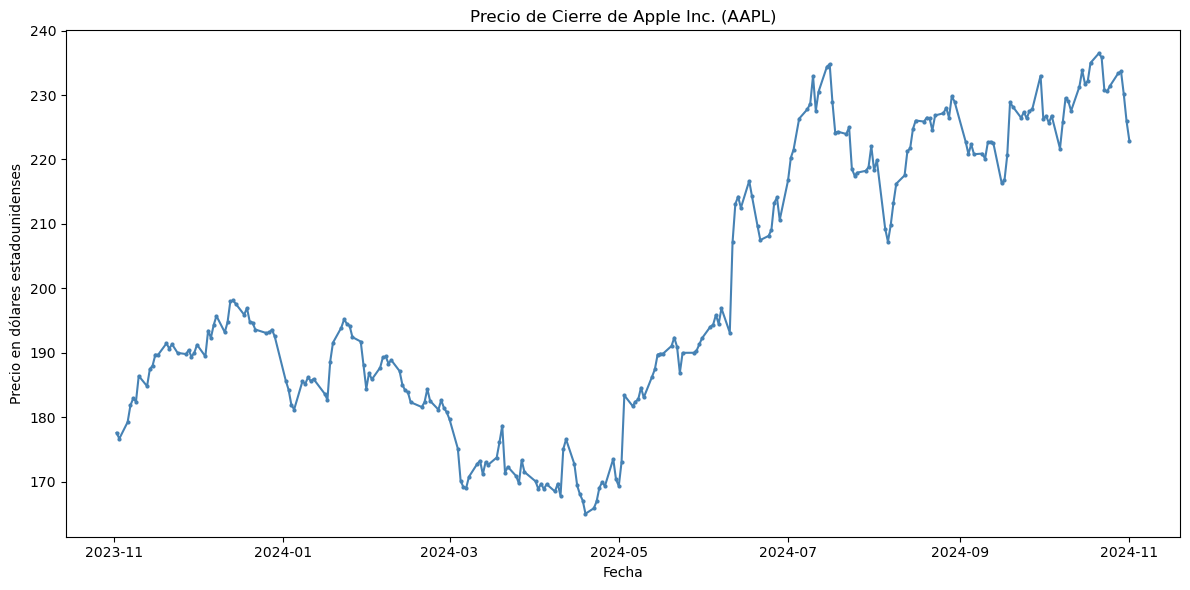

In [5]:
# Usar la columna de precio de cierre (Close) como serie principal
apple_close = df['Close']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, apple_close, marker='o', markersize=2, color='steelblue')
ax.set_title('Precio de Cierre de Apple Inc. (AAPL)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio en dólares estadounidenses')
plt.tight_layout()
plt.show()

## Verificar estacionaridad de la serie original

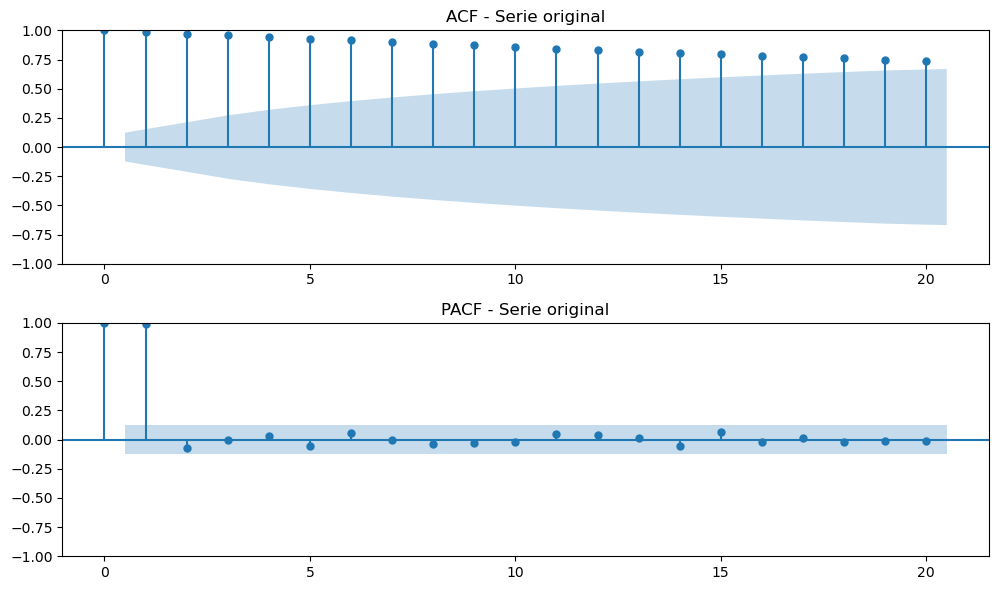

In [6]:
# Graficar la función de ACF y PACF
def graficar_autocorrelacion(data, title, maxlag=20):
    fig, axes = plt.subplots(2, 1, figsize=(10, 6))
    plot_acf(data, lags=maxlag, ax=axes[0], title=f'ACF - {title}')
    plot_pacf(data, lags=maxlag, ax=axes[1], title=f'PACF - {title}')
    plt.tight_layout()
    plt.show()

graficar_autocorrelacion(apple_close, title="Serie original")

In [7]:
def test_autocorrelacion(datos, n_lags=20):
    # Ljung-Box (Prueba global)
    lb_test        = acorr_ljungbox(datos, lags=n_lags, return_df=True)
    min_p_value    = lb_test['lb_pvalue'].min()
    lb_stat        = lb_test.loc[lb_test['lb_pvalue'] == min_p_value, 'lb_stat'].iloc[0]

    # Durbin-Watson (Autocorrelación de primer orden)
    dw_stat = durbin_watson(datos)

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Durbin-Watson", f"Ljung-Box (hasta lag {n_lags})"],
        'Estadístico' : [round(dw_stat, 4), round(lb_stat, 4)],
        'P-valor'     : [None, round(min_p_value, 4)]
    })

    # Conclusiones
    dw_conclu = (
        "Sin autocorrelación" if 1.5 < dw_stat < 2.5 else
        "Autocorrelación positiva" if dw_stat < 1.5 else
        "Autocorrelación negativa"
    )
    lb_conclu = "Sin autocorrelación" if min_p_value > 0.05 else "Autocorrelación detectada"
    tab_test['Conclusión'] = [dw_conclu, lb_conclu]

    print("=" * 80)
    print("PRUEBA DE LJUNG-BOX Y DURBIN-WATSON")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)

test_autocorrelacion(apple_close.dropna(), n_lags=20)

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                       Test  Estadístico  P-valor                 Conclusión
0             Durbin-Watson       0.0002      NaN   Autocorrelación positiva
1  Ljung-Box (hasta lag 20)    1604.7572      0.0  Autocorrelación detectada


In [8]:
def test_estacionariedad(datos):
    # Augmented Dickey-Fuller
    adf_result = adfuller(datos)
    # KPSS
    kpss_result = kpss(datos, regression='c')

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Prueba Augmented Dickey-Fuller (ADF)", "Prueba KPSS"],
        'Estadístico' : [round(adf_result[0],  4), round(kpss_result[0],  4)],
        'P-valor'     : [round(adf_result[1], 4), round(kpss_result[1], 4)],
        "Estacionario" : ["Sí" if adf_result[1] < 0.05 else "No", "No" if kpss_result[1] < 0.05 else "Sí"]
    })

    print("=" * 80)
    print("PRUEBA DE ESTACIONARIEDAD")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)


test_estacionariedad(apple_close.dropna())

PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)      -1.0154   0.7476           No
1                           Prueba KPSS       1.6499   0.0100           No


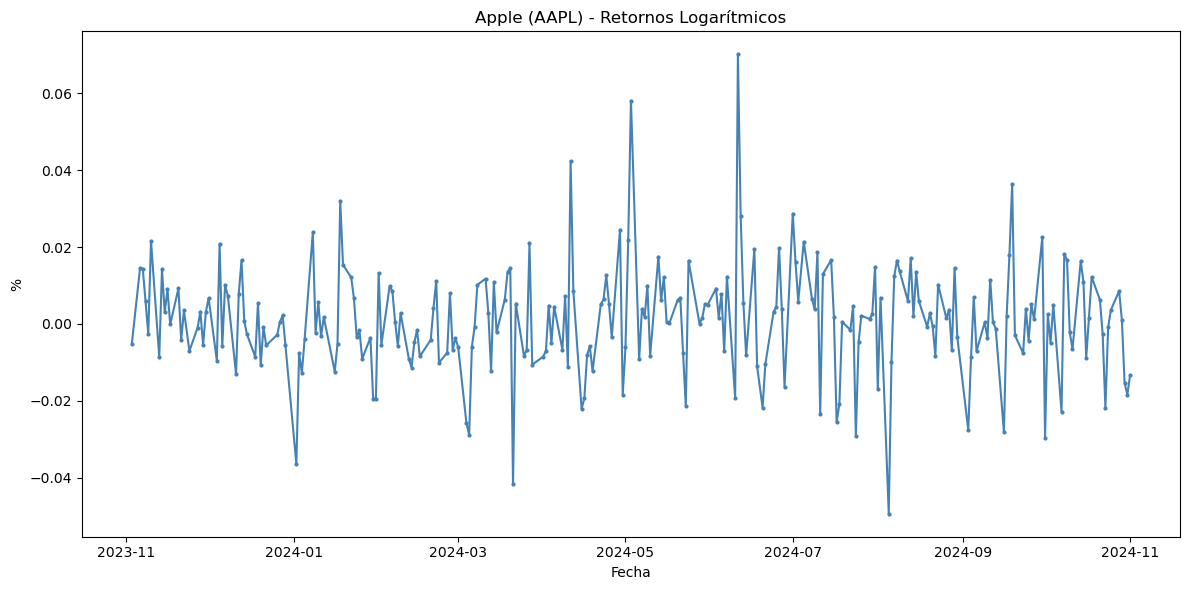

In [9]:
# Primera diferencia de la serie
apple_diff = apple_close.dropna().diff().dropna()

# Logaritmo y primera diferencia (tasas de crecimiento/retornos logarítmicos)
apple_log = np.log(apple_close.dropna())
apple_crecimiento = apple_log.diff().dropna()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(apple_crecimiento, marker='o', markersize=2, color='steelblue')
ax.set_title('Apple (AAPL) - Retornos Logarítmicos')
ax.set_xlabel('Fecha')
ax.set_ylabel('%')
plt.tight_layout()
plt.show()

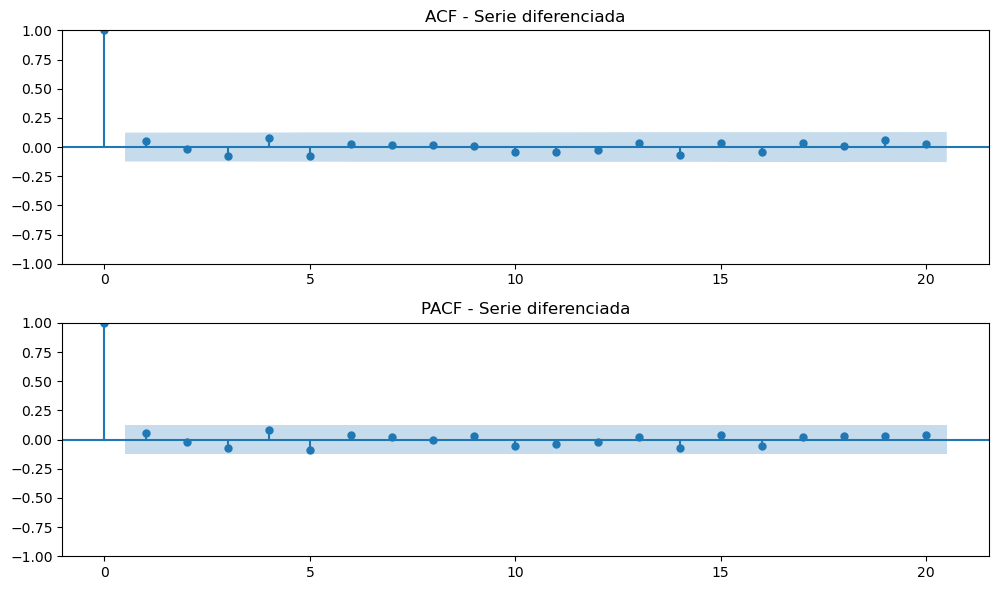

PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)     -14.9092      0.0           Sí
1                           Prueba KPSS       0.0976      0.1           Sí


In [10]:
# Graficar la función de ACF y PACF de la serie diferenciada
graficar_autocorrelacion(apple_diff, title="Serie diferenciada")

# Test estacionariedad
test_estacionariedad(apple_diff)

## Estimación modelos ARIMA

In [11]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA(1, 0, 0) sobre los retornos logarítmicos
m_arima110 = ARIMA(apple_crecimiento, order=(1, 0, 0)).fit()
print(m_arima110.summary())

# Guardar modelos estimados
modelos = {}
modelos["ARIMA(1, 1, 0)"] = m_arima110

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  251
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 713.247
Date:                Sat, 11 Apr 2026   AIC                          -1420.494
Time:                        11:17:16   BIC                          -1409.918
Sample:                             0   HQIC                         -1416.238
                                - 251                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.001      0.945      0.345      -0.001       0.003
ar.L1          0.0506      0.056      0.905      0.365      -0.059       0.160
sigma2         0.0002   1.11e-05     17.968      0.0

In [12]:
# ARIMA(0, 0, 1) sobre los retornos logarítmicos
m_arima011 = ARIMA(apple_crecimiento, order=(0, 0, 1)).fit()
print(m_arima011.summary())

# Guardar
modelos["ARIMA(0, 1, 1)"] = m_arima011

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  251
Model:                 ARIMA(0, 0, 1)   Log Likelihood                 713.253
Date:                Sat, 11 Apr 2026   AIC                          -1420.507
Time:                        11:17:52   BIC                          -1409.930
Sample:                             0   HQIC                         -1416.251
                                - 251                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.001      0.952      0.341      -0.001       0.003
ma.L1          0.0484      0.055      0.882      0.378      -0.059       0.156
sigma2         0.0002   1.11e-05     17.933      0.0

In [13]:
# ARIMA(1, 0, 1) sobre los retornos logarítmicos
m_arima111 = ARIMA(apple_crecimiento, order=(1, 0, 1)).fit()
print(m_arima111.summary())

# Guardar
modelos["ARIMA(1, 1, 1)"] = m_arima111

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  251
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 713.210
Date:                Sat, 11 Apr 2026   AIC                          -1418.421
Time:                        11:18:15   BIC                          -1404.319
Sample:                             0   HQIC                         -1412.746
                                - 251                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.001      0.941      0.346      -0.001       0.003
ar.L1          0.1642      1.495      0.110      0.913      -2.766       3.094
ma.L1         -0.1157      1.486     -0.078      0.9

In [14]:
# Auto-ARIMA encuentra los parámetros óptimos automáticamente
m_autoARIMA = auto_arima(apple_crecimiento, 
                         seasonal=False,      # No seasonal
                         stepwise=True,       # Búsqueda por pasos
                         trace=True,          # Mostrar progreso
                         error_action='ignore',
                         suppress_warnings=True,
                         start_p=0, start_q=0, max_p=5, max_q=5, d=0)

print("Auto-ARIMA")
print(m_autoARIMA.summary())
print(f'Parámetros óptimos: ARIMA{m_autoARIMA.order}')

modelos["auto-ARIMA"] = ARIMA(apple_crecimiento, order=(1, 0, 0), trend="c").fit()

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-1422.827, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-1421.577, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-1421.584, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-1419.552, Time=0.19 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-1421.856, Time=0.07 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0]          
Total fit time: 0.450 seconds
Auto-ARIMA
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  251
Model:                        SARIMAX   Log Likelihood                 712.413
Date:                Sat, 11 Apr 2026   AIC                          -1422.827
Time:                        11:18:42   BIC                          -1419.301
Sample:                             0   HQIC                         -1421.408
                                - 251                       

In [15]:
def comparar_modelos_arima(modelos: dict) -> pd.DataFrame:
    df_modelos = (
        pd.DataFrame({
            "Modelo"  : list(modelos),
            "AIC"     : [m.aic       for m in modelos.values()],
            "AICc"    : [m.aicc      for m in modelos.values()],
            "BIC"     : [m.bic       for m in modelos.values()],
            "Log-Lik" : [m.llf       for m in modelos.values()],
            "MSE"     : [m.mse       for m in modelos.values()],
            "RMSE"    : [m.mse**0.5  for m in modelos.values()],
            "MAE"     : [m.mae       for m in modelos.values()],
            "Params"  : [m.df_model  for m in modelos.values()],
            "Obs"     : [m.nobs      for m in modelos.values()],
        })
        .sort_values("AICc")
        .assign(Ranking=lambda df: range(1, len(df) + 1))
        .set_index("Ranking")
    )

    mejor      = df_modelos.iloc[0]["Modelo"]
    mejor_aicc = df_modelos.iloc[0]["AICc"]

    print("=" * 100)
    print("COMPARACIÓN DE MODELOS ARIMA")
    print("=" * 100)
    print(df_modelos.to_string())
    print("-" * 100)
    print(f"Mejor modelo (menor AICc): {mejor}  →  AICc: {mejor_aicc}")
    print("=" * 100)

comparar_modelos_arima(modelos)

mejor_modelo = modelos['ARIMA(1, 1, 0)']

COMPARACIÓN DE MODELOS ARIMA
                 Modelo          AIC         AICc          BIC     Log-Lik       MSE      RMSE       MAE  Params  Obs
Ranking                                                                                                              
1        ARIMA(0, 1, 1) -1420.506778 -1420.409612 -1409.930419  713.253389  0.000199  0.014114  0.010240       3  251
2        ARIMA(1, 1, 0) -1420.494499 -1420.397333 -1409.918140  713.247250  0.000199  0.014114  0.010238       3  251
3            auto-ARIMA -1420.494499 -1420.397333 -1409.918140  713.247250  0.000199  0.014114  0.010238       3  251
4        ARIMA(1, 1, 1) -1418.420934 -1418.258332 -1404.319122  713.210467  0.000199  0.014116  0.010235       4  251
----------------------------------------------------------------------------------------------------
Mejor modelo (menor AICc): ARIMA(0, 1, 1)  →  AICc: -1420.4096119364208


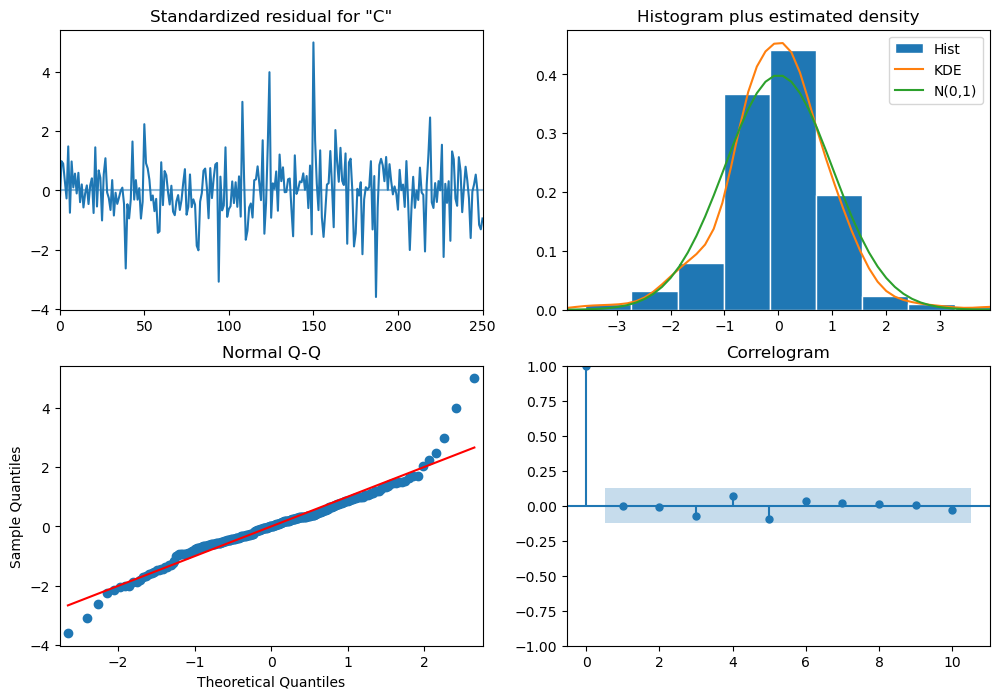

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                       Test  Estadístico  P-valor           Conclusión
0             Durbin-Watson       1.9941      NaN  Sin autocorrelación
1  Ljung-Box (hasta lag 20)       4.9953   0.4165  Sin autocorrelación


In [16]:
# Verificar ruido blanco
# Diagnóstico del modelo
def plot_diagnostics(modelo, n_lags=10):
    if not "statsmodels" in str(type(modelo)):
        raise TypeError("El objeto debe ser un modelo ajustado de statsmodels.")

    # Diagnóstico
    modelo.plot_diagnostics(figsize=(12, 8))
    plt.show()

    # test_autocorrelacion
    test_autocorrelacion(modelo.resid, n_lags=n_lags)

# Ejecución de la función
plot_diagnostics(modelo=mejor_modelo, n_lags=20)

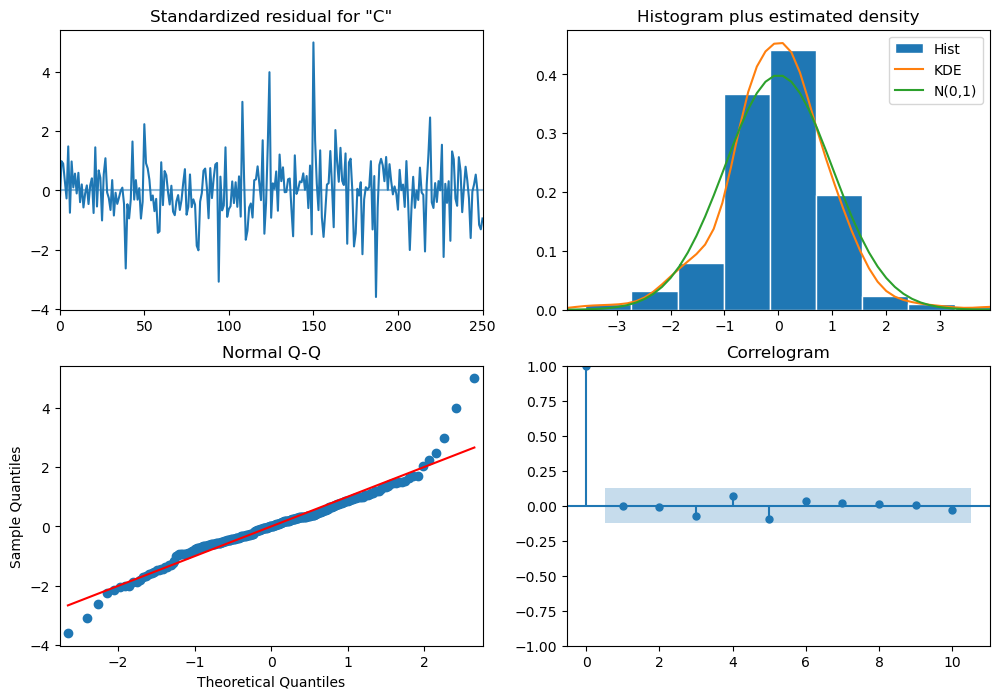

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                       Test  Estadístico  P-valor           Conclusión
0             Durbin-Watson       1.9941      NaN  Sin autocorrelación
1  Ljung-Box (hasta lag 20)       4.9953   0.4165  Sin autocorrelación


In [17]:
# Verificar ruido blanco
plot_diagnostics(modelo=mejor_modelo, n_lags=20)

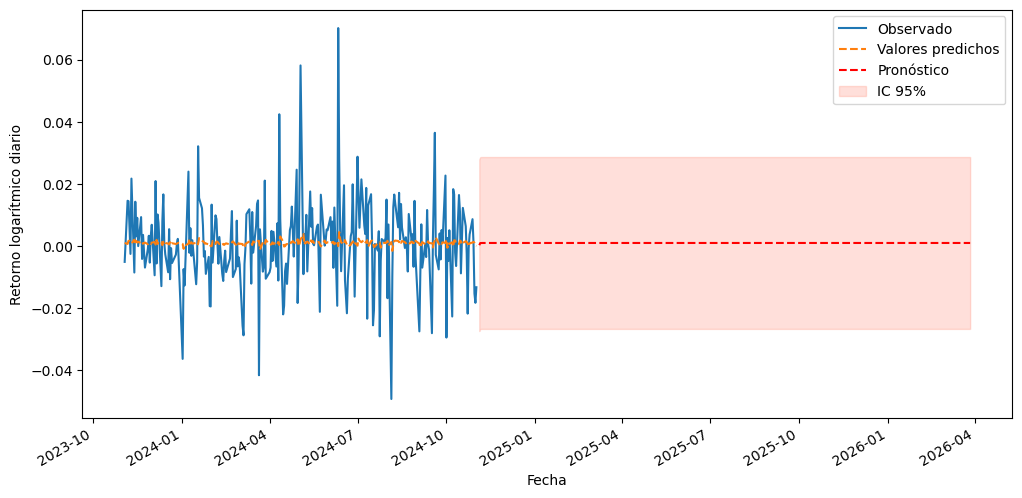

                           Pronóstico  IC Inferior  IC Superior
Fecha                                                          
2024-11-04 00:00:00+00:00    0.000177    -0.027476     0.027831
2024-11-05 00:00:00+00:00    0.000863    -0.026826     0.028551
2024-11-06 00:00:00+00:00    0.000897    -0.026792     0.028586
2024-11-07 00:00:00+00:00    0.000899    -0.026790     0.028588
2024-11-08 00:00:00+00:00    0.000899    -0.026790     0.028588
2024-11-11 00:00:00+00:00    0.000899    -0.026790     0.028588
2024-11-12 00:00:00+00:00    0.000899    -0.026790     0.028588
2024-11-13 00:00:00+00:00    0.000899    -0.026790     0.028588
2024-11-14 00:00:00+00:00    0.000899    -0.026790     0.028588
2024-11-15 00:00:00+00:00    0.000899    -0.026790     0.028588
2024-11-18 00:00:00+00:00    0.000899    -0.026790     0.028588
2024-11-19 00:00:00+00:00    0.000899    -0.026790     0.028588
2024-11-20 00:00:00+00:00    0.000899    -0.026790     0.028588
2024-11-21 00:00:00+00:00    0.000899   

In [18]:
# Pronóstico de los próximos 365 días hábiles (bursátiles)
t_pronostico    = 365
ultima_fecha    = apple_crecimiento.index[-1]
fechas_pronostico = pd.bdate_range(start=ultima_fecha + pd.Timedelta(days=1), periods=t_pronostico)

# Obtener valores promedio e intervalos del pronóstico
pronostico_apple = mejor_modelo.get_forecast(steps=t_pronostico)
pred_mean        = pronostico_apple.predicted_mean
pred_ci          = pronostico_apple.conf_int()

# Alinear índice con fechas bursátiles
pred_mean.index = fechas_pronostico
pred_ci.index   = fechas_pronostico

# Graficar resultados pronóstico
plt.figure(figsize=(12, 6))
ax = apple_crecimiento.plot(label="Observado")
plt.plot(mejor_modelo.fittedvalues.index, mejor_modelo.fittedvalues, label="Valores predichos", linestyle="--")
pred_mean.plot(ax=ax, label="Pronóstico", linestyle="--", color="red")
ax.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    color='tomato', alpha=.2, label="IC 95%"
)
ax.set_xlabel('Fecha')
ax.set_ylabel('Retorno logarítmico diario')
ax.legend()
plt.show()

# Tabla de pronóstico
df_forecast = pd.DataFrame({
    "Pronóstico"  : pred_mean,
    "IC Inferior" : pred_ci.iloc[:, 0],
    "IC Superior" : pred_ci.iloc[:, 1]
})
df_forecast.index.name = "Fecha"
print(df_forecast.to_string())

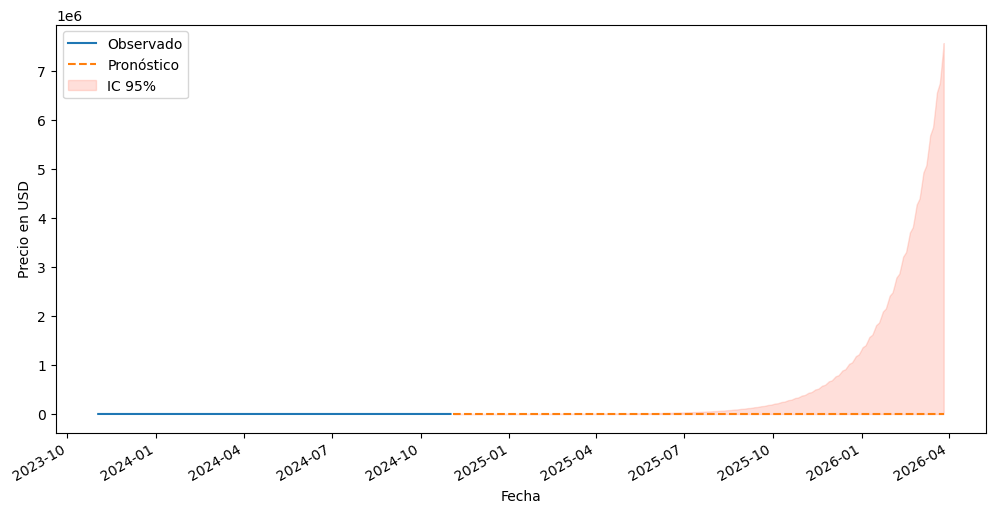

                           Pronóstico  IC Inferior   IC Superior
Fecha                                                           
2024-11-04 00:00:00+00:00  222.949552   216.868670  2.292009e+02
2024-11-05 00:00:00+00:00  223.141948   211.128222  2.358393e+02
2024-11-06 00:00:00+00:00  223.342249   205.546827  2.426783e+02
2024-11-07 00:00:00+00:00  223.543123   200.113332  2.497161e+02
2024-11-08 00:00:00+00:00  223.744197   194.823486  2.569581e+02
2024-11-11 00:00:00+00:00  223.945453   189.673474  2.644100e+02
2024-11-12 00:00:00+00:00  224.146890   184.659598  2.720781e+02
2024-11-13 00:00:00+00:00  224.348508   179.778260  2.799685e+02
2024-11-14 00:00:00+00:00  224.550307   175.025957  2.880878e+02
2024-11-15 00:00:00+00:00  224.752288   170.399278  2.964425e+02
2024-11-18 00:00:00+00:00  224.954451   165.894901  3.050395e+02
2024-11-19 00:00:00+00:00  225.156796   161.509594  3.138859e+02
2024-11-20 00:00:00+00:00  225.359322   157.240209  3.229888e+02
2024-11-21 00:00:00+00:00

In [19]:
# Revertir log-diferencia a niveles (precio)
ultimo_precio_nivel = apple_close.dropna().iloc[-1]

pred_niveles    = ultimo_precio_nivel * np.exp(pred_mean.cumsum())
pred_ci_niveles = pd.DataFrame({
    "lower": ultimo_precio_nivel * np.exp(pred_ci.iloc[:, 0].cumsum()),
    "upper": ultimo_precio_nivel * np.exp(pred_ci.iloc[:, 1].cumsum())
}, index=pred_mean.index)

# Graficar resultados pronóstico en niveles
plt.figure(figsize=(12, 6))
ax = apple_close.plot(label="Observado")
pred_niveles.plot(ax=ax, label="Pronóstico", linestyle="--")
ax.fill_between(
    pred_ci_niveles.index,
    pred_ci_niveles["lower"],
    pred_ci_niveles["upper"],
    color="tomato", alpha=0.2, label="IC 95%"
)
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio en USD')
ax.legend()
plt.show()

# Tabla de pronóstico en niveles
df_forecast = pd.DataFrame({
    "Pronóstico"  : pred_niveles,
    "IC Inferior" : pred_ci_niveles["lower"],
    "IC Superior" : pred_ci_niveles["upper"],
})
df_forecast.index.name = "Fecha"
print(df_forecast.to_string())